In [149]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "2"
import sys
sys.path.append('/home/chinfo/JupyterProjects/DIKI2/')

import numpy as np
from tqdm import tqdm
import tensorflow as tf
from tensorflow import keras
from sklearn.decomposition import PCA
# gpu = tf.config.list_physical_devices('GPU')
# tf.config.experimental.set_memory_growth(gpu[0], True)

from flow import RealNVP
from training import training_loop
from estimating import inference_realnvp as inference
from calcp import cal_pxy

import matplotlib.pyplot as plt
from scipy.signal import savgol_filter,find_peaks,peak_widths

import matplotlib as mpl
mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['xtick.direction'] = 'in'
mpl.rcParams['ytick.direction'] = 'in'
mpl.rcParams['xtick.major.size'] = 3
mpl.rcParams['ytick.major.size'] = 3
mpl.rcParams['xtick.minor.size'] = 3
mpl.rcParams['ytick.minor.size'] = 3
mpl.rcParams['xtick.labelsize'] = 16
mpl.rcParams['ytick.labelsize'] = 16
mpl.rcParams['axes.labelsize'] = 16
mpl.rcParams['legend.fontsize'] = 16
mpl.rcParams['legend.frameon'] = False
mpl.rcParams["axes.labelpad"] = -0.5

# load dcd

In [2]:
import MDAnalysis as mda

In [99]:
# traj_pos = []
# traj = mda.Universe('output/muller2.dcd')
# for i in tqdm(traj.trajectory[::1]):
#     traj_pos.append(traj.atoms.positions[0].copy())
# traj_pos = np.vstack(traj_pos)
# np.save('traj.npy',traj_pos[:,:]/10)

# load data

In [100]:
data_npz = np.load('traj.npy')
data = data_npz[:,:2]
feature_number = data.shape[1]

In [101]:
Px_truth = -(1./4. * data[:,0]**4 - 3 * data[:,0]**2 + data[:,0])/(0.00198719*300)

In [102]:
# random_stack = np.random.normal(size=(len(data),9))
# data = np.hstack((data,random_=stack))

# from sklearn.preprocessing import StandardScaler
# scaler = StandardScaler()
# data = scaler.fit_transform(data)

<ipython-input-103-08bc48bfc92c>:2: RuntimeWarning: divide by zero encountered in log
  Heatmap = -np.log(H)*(0.00198719*300)


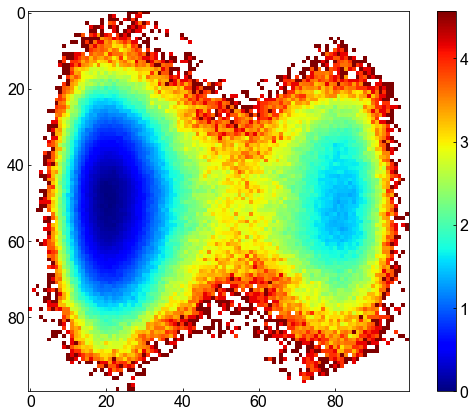

In [103]:
H,xedges,yedges = np.histogram2d(data[:,0],data[:,1],bins=100)
Heatmap = -np.log(H)*(0.00198719*300)
Heatmap -= Heatmap.min()
plt.figure(figsize=[10,7])
plt.imshow(Heatmap.T[::-1],cmap='jet')
plt.colorbar()

# Px

In [8]:
# real_nvp = RealNVP(data.shape[1],32,1e-3,12)
# _ = real_nvp(data[:32])

In [9]:
real_nvp = RealNVP(data.shape[1],4,0.0,12)
_ = real_nvp(data[:32])

In [10]:
# savebestmodel = keras.callbacks.ModelCheckpoint('px_flow_100D.h5',save_best_only=True,save_weights_only=True,monitor='loss',verbose=1)

# real_nvp.compile(optimizer=keras.optimizers.Adam(learning_rate=5e-4))

# history = real_nvp.fit(data[np.random.permutation(np.arange(len(data)))], batch_size=10000,\
#                        epochs=100000,verbose=1,callbacks=savebestmodel,shuffle=True)

In [66]:
# real_nvp.load_weights('px_flow_100D.h5')
gauss_trans,log_Jacobian,d2p_dx2,Px = \
inference(real_nvp,data,batch_size=200000)

100%|██████████| 5/5 [00:01<00:00,  4.72it/s]


In [12]:
# plt.figure()
# plt.scatter(Px_truth,Px,s=0.001)
# plt.xlim([0,20])

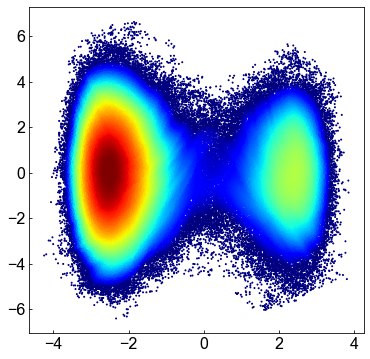

In [46]:
plt.figure(figsize=[6,6])
plt.scatter(data[:,0],data[:,1],s=1,c=Px,cmap='jet')
plt.clim([np.percentile(Px,1),np.percentile(Px,95)])

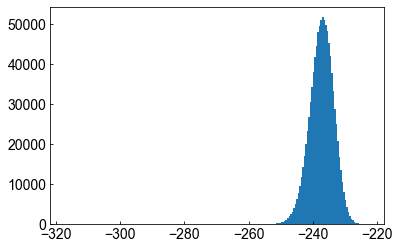

In [29]:
plt.figure()
_ = plt.hist(Px,bins=200)

# PXY

In [258]:
from jointdata import Jointdata
lag_time = 1
Data = Jointdata()
joint_data = Data.gen_data(data,lag_time=lag_time)
data_pxy,data_pyx = joint_data
joint_data_training = np.vstack((data_pxy,data_pyx))

In [259]:
real_nvp = RealNVP(feature_number*2,8,0,12)
_ = real_nvp(np.zeros((32,feature_number*2)))

In [161]:
savebestmodel = keras.callbacks.ModelCheckpoint(f'pxy_flow_lagtime{lag_time}.h5',save_best_only=True,\
                                                save_weights_only=True,monitor='loss',verbose=1)

real_nvp.compile(optimizer=keras.optimizers.Adam(learning_rate=3e-4))

history = real_nvp.fit(
     joint_data_training[np.random.permutation(np.arange(len(joint_data_training)))], batch_size=1024, epochs=200,\
     verbose=1,callbacks=savebestmodel
)

Epoch 1/200
1953/1954 [============================>.] - ETA: 0s - loss: 2.8317
Epoch 1: loss improved from inf to 2.83120, saving model to pxy_flow_lagtime1.h5
1954/1954 [==============================] - 154s 63ms/step - loss: 2.8312
Epoch 2/200
1954/1954 [==============================] - ETA: 0s - loss: 1.8768
Epoch 2: loss improved from 2.83120 to 1.87680, saving model to pxy_flow_lagtime1.h5
1954/1954 [==============================] - 123s 63ms/step - loss: 1.8768
Epoch 3/200
1954/1954 [==============================] - ETA: 0s - loss: 1.8573
Epoch 3: loss improved from 1.87680 to 1.85727, saving model to pxy_flow_lagtime1.h5
1954/1954 [==============================] - 124s 64ms/step - loss: 1.8573
Epoch 4/200
1954/1954 [==============================] - ETA: 0s - loss: 1.8498
Epoch 4: loss improved from 1.85727 to 1.84981, saving model to pxy_flow_lagtime1.h5
1954/1954 [==============================] - 124s 63ms/step - loss: 1.8498
Epoch 5/200
1954/1954 [=====================


KeyboardInterrupt



In [260]:
real_nvp.load_weights('pxy_flow_lagtime1.h5') 

In [20]:
gauss_trans,log_Jacobian,d2p_dx2,Pxy1 = \
inference(real_nvp,data_pxy,batch_size=200000)

gauss_trans,log_Jacobian,d2p_dx2,Pxy2 = \
inference(real_nvp,data_pyx,batch_size=200000)

100%|██████████| 4/4 [00:00<00:00, 10.99it/s]


In [21]:
# Pxy_svg = (Pxy1 + Pxy2)/2
# Pxcy = Pxy_svg - Px[:-1]

Pxy = (Pxy1 + Pxy2)/2

# remove outlier
lb = 0.1
ub = 100 - lb

Px_lb = np.percentile(Px,lb)
Px_ub = np.percentile(Px,ub)
Px_lb_idx = np.where(Px < Px_lb)[0]
Px_ub_idx = np.where(Px > Px_ub)[0]
Px[Px_lb_idx] = Px_lb
Px[Px_ub_idx] = Px_ub

Pxy_lb = np.percentile(Pxy,lb)
Pxy_ub = np.percentile(Pxy,ub)
Pxy_lb_idx = np.where(Pxy < Pxy_lb)[0]
Pxy_ub_idx = np.where(Pxy > Pxy_ub)[0]
Pxy[Pxy_lb_idx] = Pxy_lb
Pxy[Pxy_ub_idx] = Pxy_ub

Pxcy_log = Pxy - Px[:-lag_time]
Pxcy = Pxy - Px[:-lag_time]

NameError: name 'Px' is not defined

In [20]:
# np.savez('P_result.npz',Px=Px,Pxcy=Pxcy)

In [22]:
npz_file = np.load('P_result.npz')
Px = npz_file['Px']
Pxcy = npz_file['Pxcy']
Pxcy_log = Pxcy

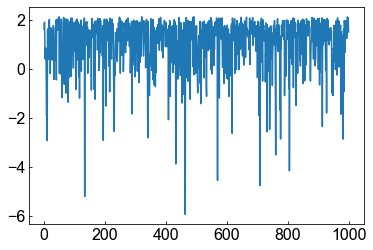

In [23]:
plt.figure()
plt.plot(Pxcy[:1000])

# 分段

In [361]:
vae_train_data = data[::]
# Px = Px[::10]
# Pxcy = Pxcy[::10]
# Pxcy_log = Pxcy_log[::10]
# from pywt import wavedec,waverec
# coeffs = wavedec(Pxcy_log, 'db14', level=10)
# for j in range(1,6):
#     coeffs[-j] = np.zeros_like(coeffs[-j])

# cwt_pxcy = waverec(coeffs,'db14')
# peaks,_ = find_peaks(-cwt_pxcy,height=-np.percentile(cwt_pxcy,20),distance=30)

from scipy.signal import savgol_filter
svg_pxcy = savgol_filter(-Px,50,1,0)
peaks,_ = find_peaks(svg_pxcy,height=np.percentile(svg_pxcy,1),distance=50)
# peaks = np.where(svg_pxcy>np.percentile(svg_pxcy,99))[0]
results_half = peak_widths(svg_pxcy, peaks, rel_height=0.3)
left = np.int64(peaks - (peaks - results_half[2])*3)
right =  np.int64((results_half[3] - peaks)*3 + peaks)

left = np.append(left,len(Px))
right = np.insert(right,0,0)

peaks = np.append(peaks,len(Px))
indice = np.concatenate([right[...,None],left[...,None]],axis=1)
indice = np.delete(indice,np.where(indice[:,0]>=indice[:,1])[0],axis=0)

In [362]:
not_sure_indice = np.zeros((len(indice)+1,2),dtype='int64')
not_sure_indice[1:,0] = indice[:,1]
not_sure_indice[:-1,1] = indice[:,0]
not_sure_indice[-1,1] = len(Px)
not_sure_indice = np.delete(not_sure_indice,np.where(not_sure_indice[:,0]==not_sure_indice[:,1])[0],axis=0)
assert (not_sure_indice[:,0]<not_sure_indice[:,1]).all()

(-50.0, 10050.0)

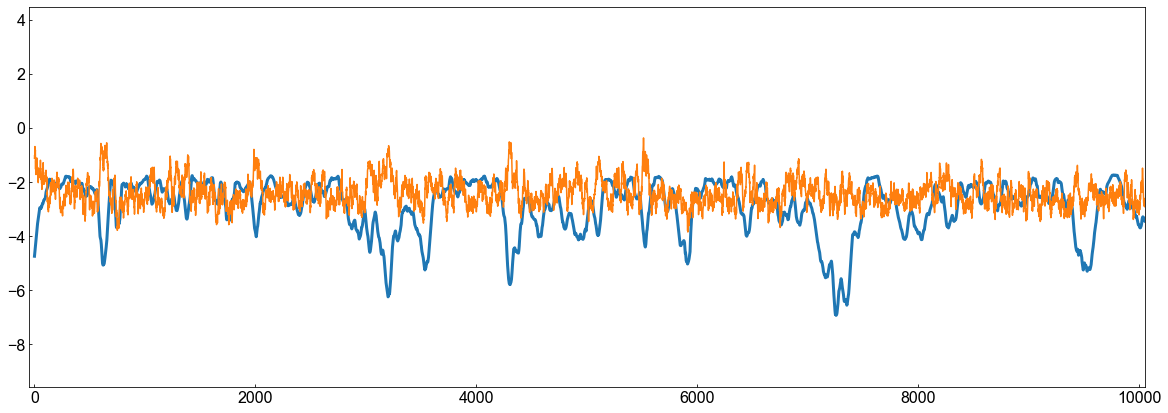

In [363]:
plt.figure(figsize=[20,7])
plt.plot(-svg_pxcy[:],lw=3)
# plt.plot(-svg_pxcy[:],lw=3)
plt.plot(data[:,0])
plt.xlim([-50,10050])

In [364]:
labels = -1*np.ones(len(Px),dtype='int64')
representative_structures = np.zeros((len(indice),vae_train_data.shape[1]))
representative_P = np.zeros(len(indice))

for i,ind in enumerate(indice):
    labels[ind[0]:ind[1]] = i
    representative_P[i] = Px[ind[0]:ind[1]].mean()
    representative_structures[i] = vae_train_data[ind[0]:ind[1]][Px[ind[0]:ind[1]].argmax()]

In [315]:
from calcp import cal_pxy
mat = cal_pxy(real_nvp, representative_structures, representative_P, batch=500000)
np.save(f'mat{len(mat)}_3.npy',mat)

100%|██████████| 171/171 [00:33<00:00,  5.14it/s]


In [316]:
len(mat)

13104

In [344]:
mat = np.load(f'mat7749_2.npy')
# np.fill_diagonal(mat,mat.max(1)+1)

# improved aggregation

In [345]:
from scipy.ndimage import gaussian_filter1d
linked_mat = np.zeros_like(mat[::50,::50])
for i in range(len(linked_mat)):
    tostudy_idx = np.arange(len(mat))
    mat_idx = np.delete(tostudy_idx,i*50)
    
    freqs = np.histogram(mat[::50][i][mat_idx],bins=400)
    smoothed_freqs = gaussian_filter1d(freqs[0], sigma=2)
    
    try:
        grad = smoothed_freqs[1:]-smoothed_freqs[:-1]
        left_value2 = grad[:-4] < 0
        left_value1 = grad[1:-3] <= 0
        
        right_value1 = grad[2:-2] > 0
        right_value2 = grad[3:-1] > 0
        judge_condition1 = left_value2*left_value1*right_value1*right_value2

        left_value2 = grad[:-4] < 0
        left_value1 = grad[1:-3] < 0
        
        right_value1 = grad[2:-2] >= 0
        right_value2 = grad[3:-1] > 0
        judge_condition2 = left_value2*left_value1*right_value1*right_value2
        
        threshold_idx = np.where(judge_condition1+judge_condition2)[0].max()
        x_distribution = (freqs[1][:-1] + freqs[1][1:])/2
        dx_distribution = (x_distribution[:-1] + x_distribution[1:])/2
        threshold = (dx_distribution[threshold_idx+1] + dx_distribution[threshold_idx+2])/2
    except:
        threshold = -np.inf
    linked_mat[i][mat[::50,::50][i]<threshold] = 1
        
linked_mat += linked_mat.T
linked_mat = np.int64(linked_mat>=1)
np.fill_diagonal(linked_mat,0)

(-10.0, 50.0)

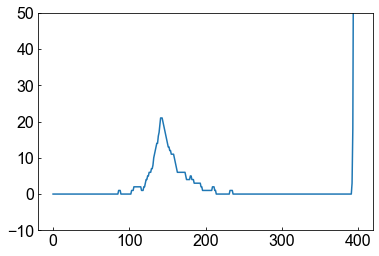

In [346]:
plt.figure()
plt.plot(smoothed_freqs)
plt.ylim([-10,50])
# plt.scatter(threshold_idx,0)

In [347]:
def self_consistent_assignment(label, mat, tolerance=5, min_cluster_size=100, patience=15,change_patient_tolerence=10,
                               _previous_change_count=-1, _unchanged_streak=0):
    """
    Performs a self-consistent assignment of labels based on a similarity matrix.

    The algorithm iteratively reassigns labels to samples based on the mean
    of features (from `mat`) for current clusters. It stops when the number
    of changed labels is below a `tolerance` or if the `change_count`
    remains the same for a specified `patience` number of rounds.
    Small clusters (below `min_cluster_size`) are merged into cluster '0'.

    Args:
        label (np.ndarray): Current assignment of labels (1D array).
                            It's assumed that the labels used in `label` and
                            those generated (`label_new`) are comparable for
                            calculating `change_count`. The algorithm implicitly
                            re-indexes new labels starting from 0.
        mat (np.ndarray): Data matrix where columns are features and rows are samples.
                          Or rows are features and columns are samples if mean is taken over samples.
                          Given `mat[:, label==i].mean(axis=-1, keepdims=True)`,
                          it implies samples are along axis 1 for the slice `mat[:, label==i]`,
                          and means are computed across these samples for each feature (row).
                          So, `mat` should be (n_features, n_samples).
        tolerance (int): The maximum number of samples that can change labels
                         for the algorithm to be considered converged.
        min_cluster_size (int): Clusters with fewer samples than this will be
                                reassigned to label 0.
        patience (int): If the `change_count` remains unchanged for this many
                        consecutive rounds, the algorithm stops and returns
                        the current `label_new`. A value <= 0 disables this feature.
        _previous_change_count (int): Internal parameter for tracking the change count
                                     from the previous iteration.
        _unchanged_streak (int): Internal parameter for tracking the number of
                                 consecutive rounds `change_count` has been stable.

    Returns:
        np.ndarray: The new assignment of labels. Labels are 0-indexed canonical
                    values based on the assignment process.
    """
    if not isinstance(label, np.ndarray):
        label = np.array(label)
    if not isinstance(mat, np.ndarray):
        mat = np.array(mat)

    if label.size == 0:
        print("Input label array is empty. Returning empty label array.")
        return np.array([]) # Return an empty numpy array consistent with type

    # --- Centroid Calculation and New Label Assignment ---
    # unique_labels_for_centroids will be sorted, e.g., [0, 1, 3]
    unique_labels_for_centroids = np.unique(label)
    
    try:
        pxcy_avg = np.hstack([mat[:, label == i].mean(axis=-1, keepdims=True)
                              for i in unique_labels_for_centroids])
    except ValueError as e:
        if "need at least one array to stack" in str(e) and unique_labels_for_centroids.size > 0:
            print(f"Error during np.hstack, possibly due to mat dimensions or empty slices despite unique labels: {e}")
            print(f"Mat shape: {mat.shape}, unique_labels_for_centroids: {unique_labels_for_centroids}")
            for i in unique_labels_for_centroids:
                print(f"  For label {i}, slice shape: {mat[:, label == i].shape}")
            return label # Cannot proceed
        raise e
        
    label_new = pxcy_avg.argmax(axis=1)
    
    change_count = (label != label_new).sum()
    print('the number of changed samples is %d' % (change_count))

    # --- Patience Logic ---
    current_unchanged_streak = _unchanged_streak
    if abs(change_count-_previous_change_count)<change_patient_tolerence:
        current_unchanged_streak += 1
    else:
        current_unchanged_streak = 0  # Reset streak if change_count changed

    # Check patience condition (only if patience is a positive value enabling the feature)
    if patience > 0 and current_unchanged_streak >= patience:
        print(f'Patience ({patience}) reached. Change count ({change_count}) '
              f'changed slightly for {current_unchanged_streak} rounds.')
        indice_not_sure = np.where(label != label_new)[0]
        return label_new,indice_not_sure  # Return the current (re-indexed) label_new
    # --- End of Patience Logic ---
    
    if change_count > tolerance:
        # `label_new` (the re-indexed labels) is used for further processing
        # and becomes the `label` for the next recursive call.
        labels_for_next_step = label_new.copy()

        unique_new_labels, counts_new = np.unique(labels_for_next_step, return_counts=True)
        small_size_cluster_label_indices = np.where(counts_new < min_cluster_size)[0]
        small_size_cluster_label = unique_new_labels[small_size_cluster_label_indices]

        if len(small_size_cluster_label_indices) == 0:
            # No small clusters to remove, recurse
            return self_consistent_assignment(labels_for_next_step, mat, tolerance, min_cluster_size,
                                              patience,change_patient_tolerence, change_count, current_unchanged_streak)
        else:
            # Small clusters found, get their actual label values (which are canonical 0-indexed)
            canonical_labels_to_reset = unique_new_labels[small_size_cluster_label_indices]
            for c_label_to_reset in canonical_labels_to_reset:
                # set transition probability of small cluster to -inf
                pxcy_avg_small_size_cluster = pxcy_avg[labels_for_next_step == c_label_to_reset]
                pxcy_avg_small_size_cluster[:,small_size_cluster_label] = -np.inf
                
                labels_for_next_step[labels_for_next_step == c_label_to_reset] = pxcy_avg_small_size_cluster.argsort(axis=1)[:,-1]
                

            return self_consistent_assignment(labels_for_next_step, mat, tolerance, min_cluster_size,
                                              patience,change_patient_tolerence, change_count, current_unchanged_streak)
    else:  # change_count <= tolerance
        print(f'Change count ({change_count}) is within tolerance ({tolerance}).')
        return label_new  # Return the current (re-indexed) label_new
    # --- End of Original Tolerance and Recursion Logic ---

In [348]:
import igraph as ig

num_vertices = len(linked_mat)
edges_mat = np.triu(linked_mat, k=0)
edges_ = np.where(edges_mat)
edges = [(i,j) for i,j in zip(*edges_)]

g = ig.Graph(n=num_vertices, edges=edges, directed=False)

largest_cliques = g.largest_cliques() # 通常返回一个或多个最大团
if largest_cliques:
    max_clique = largest_cliques[0]

In [349]:
# max_clique = find_max_clique(graph)
clique_idx = np.array([*max_clique])
label_clique = mat[:,clique_idx*50].argmax(1)

In [350]:
# updating labels
result = self_consistent_assignment(label_clique,mat,tolerance=0,min_cluster_size=10,patience=15)

the number of changed samples is 0
Change count (0) is within tolerance (0).


In [351]:
clique_idx

array([  0, 119])

In [352]:
if len(result) == 2:
    label_consistent = result[0]
    not_sure_indice_addition = indice[result[1]]
    indice = np.delete(indice,result[1],axis=0)
else:
    label_consistent = result

In [353]:
not_sure_indice = np.zeros((len(indice)+1,2),dtype='int64')
not_sure_indice[1:,0] = indice[:,1]
not_sure_indice[:-1,1] = indice[:,0]
not_sure_indice[-1,1] = len(Px)
not_sure_indice = np.delete(not_sure_indice,np.where(not_sure_indice[:,0]==not_sure_indice[:,1])[0],axis=0)
assert (not_sure_indice[:,0]<not_sure_indice[:,1]).all()

In [354]:
# aggregating labels
aggregated_labels = [np.where(label_consistent==i)[0].copy() for i in range(label_consistent.max()+1) ]

In [355]:
subgraph_id_order = np.hstack(aggregated_labels)

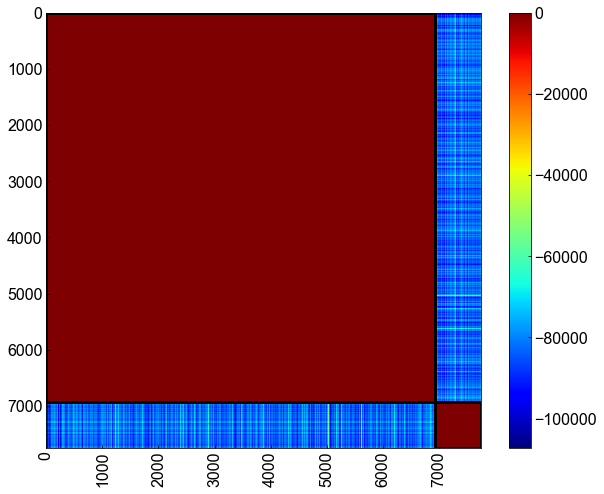

In [356]:
import matplotlib.patches as pch
plt.figure(figsize=[10,8])
plt.imshow(mat[subgraph_id_order][:,subgraph_id_order],cmap='jet')
lb = np.percentile(mat,1)
ub = np.percentile(mat,99)
plt.clim([lb,ub])
plt.colorbar()
# plt.axis('off')

max_label = len(aggregated_labels)
ax=plt.gca()
plt.xticks(rotation=90)

# add patches
for i in range(max_label):
    num = len(aggregated_labels[i])
    if i == 0:
        rct = pch.Rectangle((-0.5,-0.5),num,num,edgecolor='k',lw=3,facecolor='None')
        ax.add_patch(rct)
    else:
        start_point = sum([len(aggregated_labels[j]) for j in range(i)])
        rct = pch.Rectangle((start_point-0.5,start_point-0.5),num,num,edgecolor='k',lw=3,facecolor='None')
        ax.add_patch(rct)

In [357]:
# np.save('mat12417_ordered.npy',mat[subgraph_id_order][:,subgraph_id_order])

In [416]:
labels_aggregated = []
for i in labels:
    if i == -1:
        labels_aggregated.append(-1)
    else:
        for n,m in enumerate(aggregated_labels):
            if i in m:
                labels_aggregated.append(n)
                break
            
labels_aggregated = np.array(labels_aggregated)
# labels_aggregated[0:indice[0,0]] = labels_aggregated[indice[0,0]]

In [417]:
if not_sure_indice[0,0] == 0:
    labels_aggregated[not_sure_indice[0,0]:not_sure_indice[0,1]] = labels_aggregated[not_sure_indice[0,1]]
    for i in not_sure_indice[1:]:
        if labels_aggregated[i[0]-1] == labels_aggregated[i[1]]:
            labels_aggregated[i[0]:i[1]] = labels_aggregated[i[1]]
                
else:
    for i in not_sure_indice:
        if labels_aggregated[i[0]-1] == labels_aggregated[i[1]]:
            labels_aggregated[i[0]:i[1]] = labels_aggregated[i[1]]

(-4.2, 4.2)

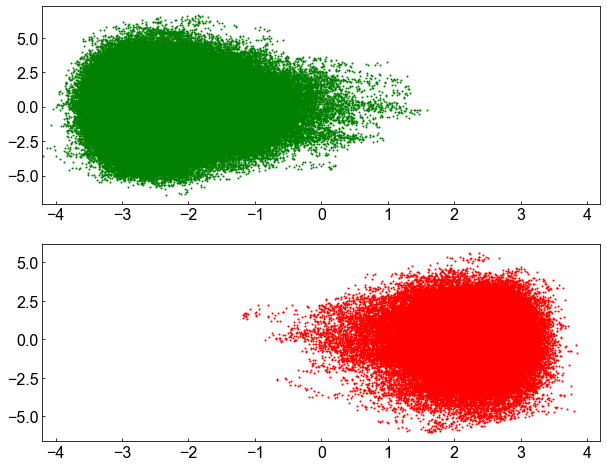

In [418]:
cluster0 = np.where(labels_aggregated==0)[0]
cluster1 = np.where(labels_aggregated==1)[0]
plt.figure(figsize=[10,8])
plt.subplot(2,1,1)
plt.scatter(data[cluster0][:,0],data[cluster0][:,1],s=1,c='g')
plt.xlim([-4.2,4.2])
plt.subplot(2,1,2)
plt.scatter(data[cluster1][:,0],data[cluster1][:,1],s=1,c='r')

plt.xlim([-4.2,4.2])

In [ ]:
# np.save(f'labels{indice.shape[0]}.npy',labels_aggregated)